# 01. PyTorch Workflow

In [1]:
import torch
from torch import nn # straight into DL
import matplotlib.pyplot as plt

torch.__version__

'2.10.0+cpu'

## Preparing and Loading Data

### Linear Regression Example

In [2]:
# Data synthesis
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10], len(X), len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

In [3]:
# Train/Test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [4]:
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions = None):
    # Note to self: Why are we doing this manually? Surely there is a built-in version of this?
    """Plots training data, test data and compares predictions."""
    plt.figure(figsize=(10,7))

    plt.scatter(train_data,train_labels,c='b',s=4,label="Training data")
    plt.scatter(test_data,test_labels,c='g',s=4,label="Testing data")
    if predictions is not None:
        plt.scatter(test_data,predictions,c='r',s=4,label="Predictions")

    plt.legend(prop={"size": 14})

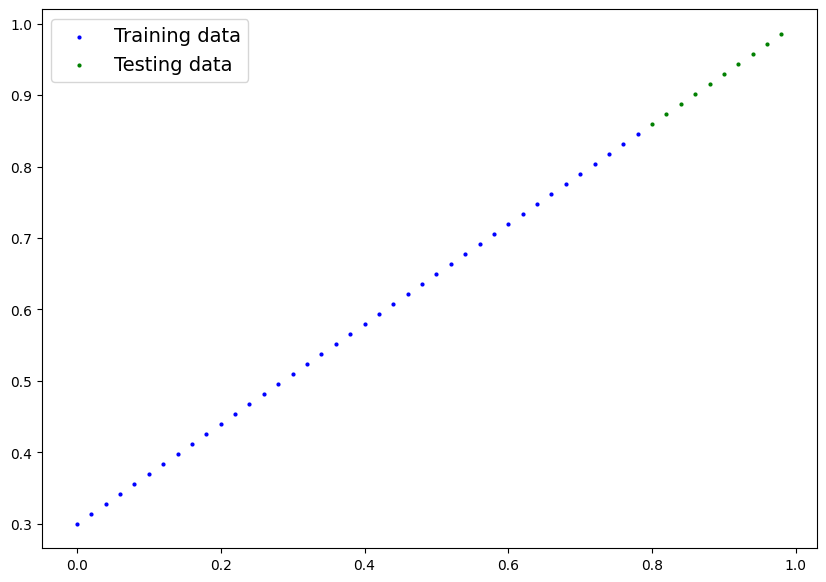

In [5]:
plot_predictions()

In [6]:
# Keep in mind that this (implementation details / algorithms)
# is abstracted away in packages such as tidymodels (R).
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Initialize model parameters
        self.weights = nn.Parameter(torch.randn(1,
                                                requires_grad=True, # default True
                                                dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                                             requires_grad=True,
                                             dtype=torch.float))
    
    # Any subclass of nn.Module needs to override the forward() method
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

### PyTorch Model Building Essentials

* torch.nn - contains all of the building blocks for computational graphs (e.g. neural networks)
* Parameter - what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us
* torch.nn.Module - the base class for all neural network modules, if you subclass it, should override forward
* torch.optim - this is where the optimizers in PyTorch live, they will help with gradient descent
* def forward() - all nn.Module subclasses require you to override forward() method. Defines what happens in the forward computation

In [7]:
# Check out model parameters
import torch
torch.manual_seed(42)

# Create an instance of the model (subclass of nn.Module)
model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [8]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [9]:
# Our ideal values 
weight, bias

(0.7, 0.3)

In [10]:
# Make predictions with models
with torch.inference_mode(): # context manager for performance
    y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

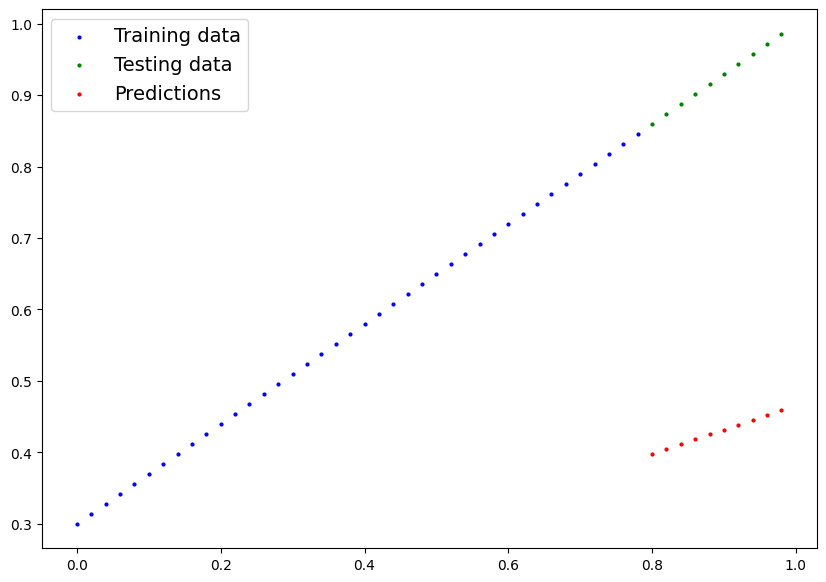

In [11]:
plot_predictions(predictions=y_preds)

## Training the model

### Loss functions & Optimizers

* Loss function measures how wrong model's predictions are
* Optimizer adjusts model parameters, taking loss into account
    * Inside the optimizers there will often be two params: `params` (iterator over model parameters) and `lr` (learning rate)

[PyTorch Loss Functions](https://docs.pytorch.org/docs/2.11/nn.html#loss-functions)

[PyTorch Optimizers](https://docs.pytorch.org/docs/2.11/optim.html#algorithms)

In [12]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [13]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup an optimizer
optimizer = torch.optim.SGD(
    params = model_0.parameters(),
    lr = 0.01
)

### Building training & testing loops

0. Loop through the data
1. Forward pass (involves data moving through model's `forward()` functions) to make predictions
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters wrt the loss (**backprop**)
5. Optimizer step - use optimizer to adjust parameters to try to improve the loss (**gradient descent**)

In [14]:
# An epoch is one loop through the data
epochs = 100

# Track the current model
epoch_count = []
loss_values = []
test_loss_values = []

### Training
# 0. Loop through the data
for epoch in range(epochs):
    # Set the model to training mode
    model_0.train() # train mode in PyTorch sets all parameters that require gradients to require gradients

    # 1. Forward pass
    y_pred = model_0(X_train)

    # 2. Calculate the loss
    loss = loss_fn(y_pred, y_train)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Perform backprop (calculate gradients wrt each parameter)
    loss.backward()
    
    # 5. Step the optimizer (perform gradient descent)
    optimizer.step() # by default how the optimizer changes will accumulate through the loop so we have to zero them


    ### Testing
    model_0.eval() # turns off different settings in the model not needed for evaluation/testing, e.g. dropout / batch norm layers but NOT gradient descent
    with torch.inference_mode(): # disables gradient tracking + more things just for efficiency
        # 1. Do the forward pass
        test_pred = model_0(X_test)
        
        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 20 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss.detach().numpy())
        test_loss_values.append(test_loss.detach().numpy())
        print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")
        print(model_0.state_dict())

Epoch: 0 | Loss: 0.31288138031959534 | Test loss: 0.48106518387794495
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch: 20 | Loss: 0.08908725529909134 | Test loss: 0.21729660034179688
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch: 40 | Loss: 0.04543796554207802 | Test loss: 0.11360953003168106
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch: 60 | Loss: 0.03818932920694351 | Test loss: 0.08886633068323135
OrderedDict({'weights': tensor([0.5116]), 'bias': tensor([0.3788])})
Epoch: 80 | Loss: 0.03132382780313492 | Test loss: 0.07232122868299484
OrderedDict({'weights': tensor([0.5459]), 'bias': tensor([0.3648])})


In [15]:
epoch_count, loss_values, test_loss_values

([0, 20, 40, 60, 80],
 [array(0.31288138, dtype=float32),
  array(0.08908726, dtype=float32),
  array(0.04543797, dtype=float32),
  array(0.03818933, dtype=float32),
  array(0.03132383, dtype=float32)],
 [array(0.48106518, dtype=float32),
  array(0.2172966, dtype=float32),
  array(0.11360953, dtype=float32),
  array(0.08886633, dtype=float32),
  array(0.07232123, dtype=float32)])

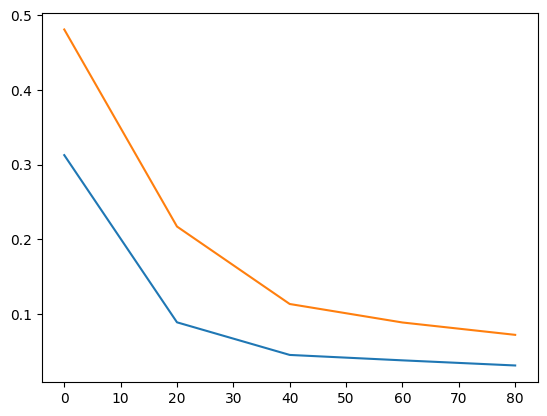

In [16]:
plt.plot(epoch_count, loss_values, label='Train loss')
plt.plot(epoch_count, test_loss_values, label = "Test loss")

In [17]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

In [18]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])

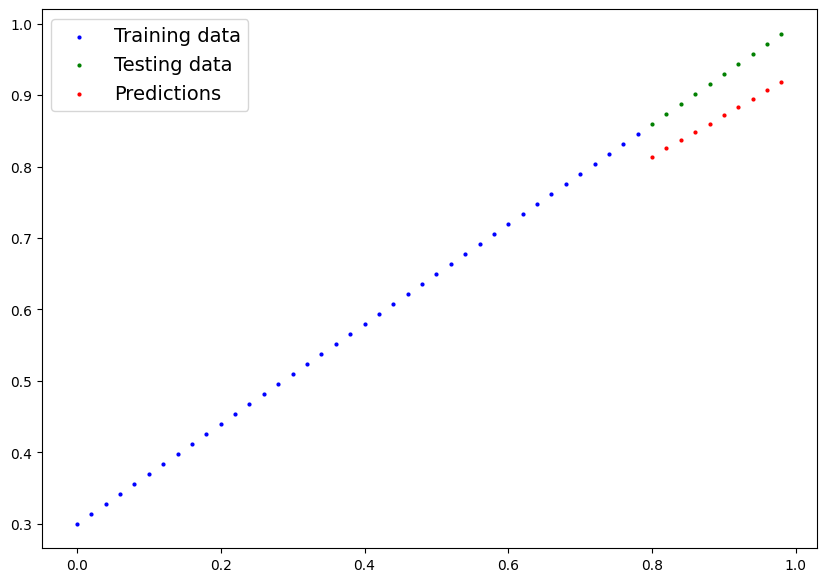

In [19]:
plot_predictions(predictions=y_preds_new)

## Saving the model

There are three main methods to save/load a model in PyTorch.

1. `torch.save()` allows you to save a PyTorch object in Python's `pickle` format
2. `torch.load()` allows you to load a saved PyTorch object
3. `torch.nn.Module.load_state_dict()` allows you to load a model's saved state dictionary to a new model

In [20]:
for param in model_0.state_dict():
    print(param, model_0.state_dict()[param], model_0.state_dict()[param].size())

weights tensor([0.5784]) torch.Size([1])
bias tensor([0.3513]) torch.Size([1])


In [23]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state_dict
torch.save(model_0.state_dict(), MODEL_SAVE_PATH)
# Loads to Colab server contents if using Colab

In [24]:
!ls -l models

total 4
-rw-r--r-- 1 root root 2117 May  7 18:09 01_pytorch_workflow_model_0.pth


## Loading a model

Since we saved `state_dict()` rather than the entire model, we'll create a new instance of our model class and load the saved `state_dict()` into that.

In [25]:
loaded_model_0 = LinearRegressionModel()

loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [26]:
# Make some predictions with our loaded model
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]])

In [29]:
model_0.eval()
with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds

tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]])

In [30]:
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## Putting it all together

In [ ]:
# Run it all from the start
import torch
from torch import nn
import matplotlib.pyplot as plt

weight = .7
bias = .3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias
# 0.8 split
X_train, y_train = X[:int(.8*len(X))], y[:int(.8*len(y))]
X_test, y_test = X[int(.8*len(X)):], y[int(.8*len(y)):]

class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Use nn.Linear()
        self.linear_layer = nn.Linear(in_features=1,
                                      out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x) # runs the layer on x
    
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()

loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(lr=0.01, params=model_1.parameters())

epochs = 200
for epoch in range(epochs):
    model_1.train()

    # 1. Forward pass
    y_pred = model_1(X_train)

    # 2. Calculate the loss
    loss = loss_fn(y_pred, y_train)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Backpropagation
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    # Shouldn't we do this every time we print, not
    # every iteration to save compute?
    model_1.eval()
    with torch.inference_mode():
        # for every iteration/epoch
        test_pred = model_1(X_test)
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")


Epoch: 0 | Loss: 0.5551779866218567 | Test loss: 0.5739762187004089
Epoch: 10 | Loss: 0.4399680495262146 | Test loss: 0.4392663538455963
Epoch: 20 | Loss: 0.3247582018375397 | Test loss: 0.30455657839775085
Epoch: 30 | Loss: 0.20954827964305878 | Test loss: 0.16984674334526062
Epoch: 40 | Loss: 0.09433844685554504 | Test loss: 0.03513689711689949
Epoch: 50 | Loss: 0.023886386305093765 | Test loss: 0.04784906655550003
Epoch: 60 | Loss: 0.0199567973613739 | Test loss: 0.04580312222242355
Epoch: 70 | Loss: 0.016517987474799156 | Test loss: 0.0375305712223053
Epoch: 80 | Loss: 0.013089170679450035 | Test loss: 0.029944902285933495
Epoch: 90 | Loss: 0.009653178043663502 | Test loss: 0.02167237363755703
Epoch: 100 | Loss: 0.006215679459273815 | Test loss: 0.014086711220443249
Epoch: 110 | Loss: 0.002787243574857712 | Test loss: 0.005814164876937866
Epoch: 120 | Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 130 | Loss: 0.0012645035749301314 | Test loss: 0.01380180753767

In [47]:
X_train[:5]

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800]])

In [54]:
model_1.eval()

with torch.inference_mode():
    y_preds = model_1(X_test)

y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]])

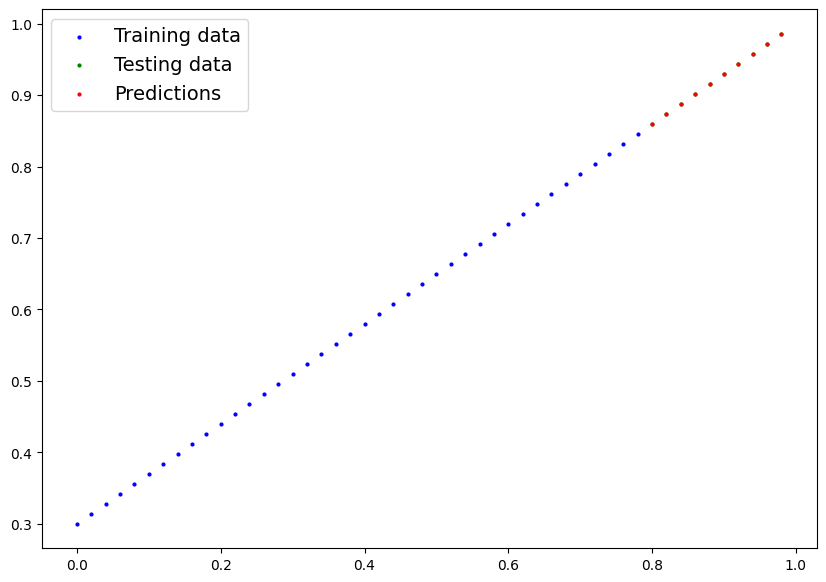

In [55]:
plot_predictions(predictions=y_preds)

In [57]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = '01_pytorch_workflow_model_1.pth'
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj=model_1.state_dict(), f=MODEL_SAVE_PATH)

In [59]:
loaded_model_1 = LinearRegressionModelV2()
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)
y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])